In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import ssl
import urllib.request
import certifi
from ucimlrepo import fetch_ucirepo

In [2]:
_real_urlopen = urllib.request.urlopen

def _patched_urlopen(url, *args, **kwargs):
    if 'context' not in kwargs:
        kwargs['context'] = ssl.create_default_context(cafile=certifi.where())
    return _real_urlopen(url, *args, **kwargs)

urllib.request.urlopen = _patched_urlopen

# fetch dataset 
auto_mpg = fetch_ucirepo(id=9)

In [56]:
#data (as pandas dataframes)
x = auto_mpg.data.features
y = auto_mpg.data.targets

df = pd.concat([x, y], axis=1)

print(f'df.head() = \n{df.head()}')
print(f'\ndf.shape = \n{df.shape}')
print(f'\ndf.columns = \n{df.columns.tolist()}')
print(f"\ndf.info() = ")
df.info()

df.head() = 
   displacement  cylinders  horsepower  weight  acceleration  model_year  \
0         307.0          8       130.0    3504          12.0          70   
1         350.0          8       165.0    3693          11.5          70   
2         318.0          8       150.0    3436          11.0          70   
3         304.0          8       150.0    3433          12.0          70   
4         302.0          8       140.0    3449          10.5          70   

   origin   mpg  
0       1  18.0  
1       1  15.0  
2       1  18.0  
3       1  16.0  
4       1  17.0  

df.shape = 
(398, 8)

df.columns = 
['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']

df.info() = 
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   displacement  398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   

In [57]:
print(df.isnull().sum())
df = df.dropna()
print()
print(df.isnull().sum())

displacement    0
cylinders       0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64

displacement    0
cylinders       0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
mpg             0
dtype: int64


In [58]:
df.insert(loc=0, column='intercept', value=1)

df_copy = df.copy()
df_copy['origin'] = df_copy['origin'].astype('category')
df_encoded = pd.get_dummies(df_copy, dtype=int, drop_first=True)

new_columns = [col for col in df_encoded.columns if col != 'mpg'] + ['mpg']
df_encoded = df_encoded[new_columns]

print(f'df.head() = \n{df.head()}')
print()
print(f'df_encoded.head() = \n{df_encoded.head()}')
print()
print(df_encoded.isnull().sum())

df_encoded.to_csv("Auto_MPG/cleaned_auto_mpg_with_intercept.csv", index=False)
print("Successfully generated cleaned_auto_mpg_with_intercept.csv")

df_order_2 = pd.get_dummies(df_copy, dtype=int, drop_first=False)

cols = ['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']

for i in range(len(cols)-3):
    for j in range(i,len(cols)):
        new_col = cols[i] + ' x ' + cols[j]
        df_order_2[new_col] = df_order_2[cols[i]] * df_order_2[cols[j]]

new_order_2_columns = [col for col in df_order_2.columns if col != 'mpg'] + ['mpg']
df_order_2 = df_order_2[new_order_2_columns]

df_order_2.to_csv("Auto_MPG/cleaned_order_2_auto_mpg_with_intercept.csv", index=False)
print("Successfully generated cleaned_order_2_auto_mpg_with_intercept.csv")

df.head() = 
   intercept  displacement  cylinders  horsepower  weight  acceleration  \
0          1         307.0          8       130.0    3504          12.0   
1          1         350.0          8       165.0    3693          11.5   
2          1         318.0          8       150.0    3436          11.0   
3          1         304.0          8       150.0    3433          12.0   
4          1         302.0          8       140.0    3449          10.5   

   model_year  origin   mpg  
0          70       1  18.0  
1          70       1  15.0  
2          70       1  18.0  
3          70       1  16.0  
4          70       1  17.0  

df_encoded.head() = 
   intercept  displacement  cylinders  horsepower  weight  acceleration  \
0          1         307.0          8       130.0    3504          12.0   
1          1         350.0          8       165.0    3693          11.5   
2          1         318.0          8       150.0    3436          11.0   
3          1         304.0        

In [59]:
print(f'\ndf_encoded.columns = \n{df_encoded.columns.tolist()}')


df_encoded.columns = 
['intercept', 'displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_2', 'origin_3', 'mpg']


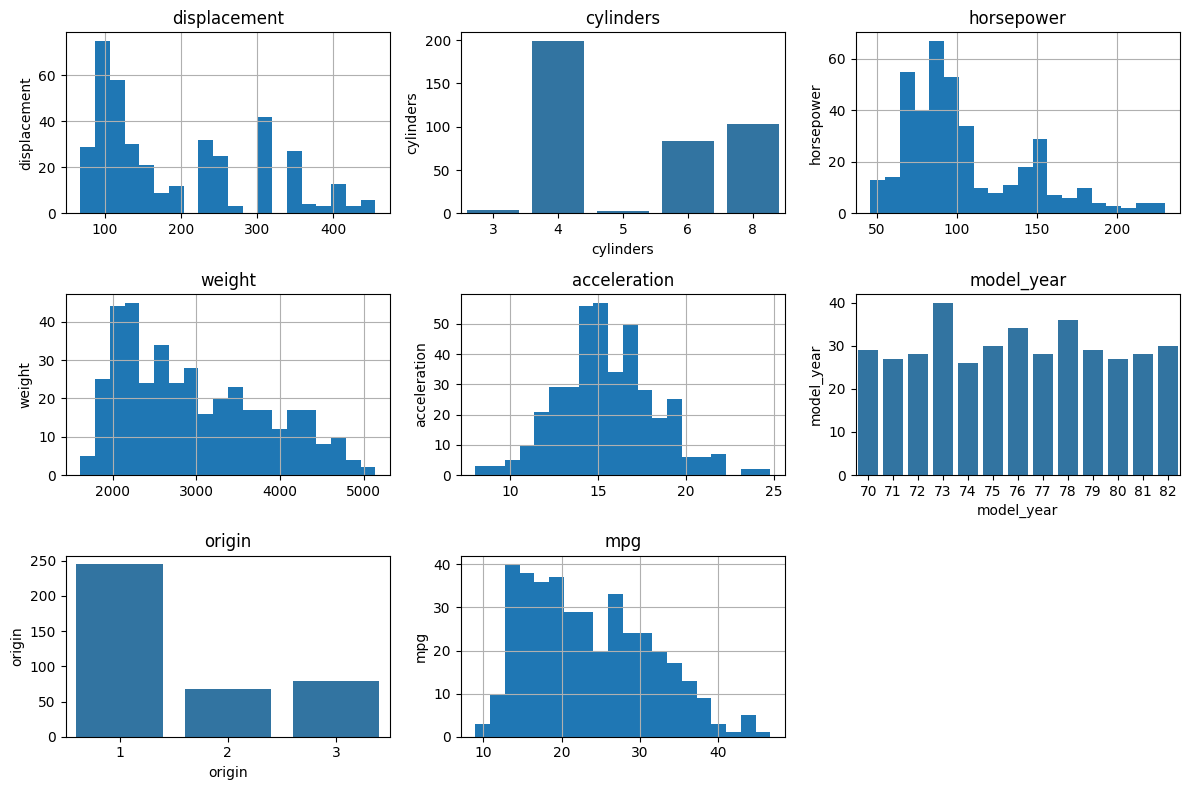

In [60]:
plt.figure(figsize=(12,8))
for i, col in enumerate(['displacement', 'cylinders', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'mpg']):
    plt.subplot(3,3,i+1)
    if col in ['cylinders', 'model_year', 'origin']:
        sns.countplot(x=col, data=df)
    else:
        df[col].hist(bins=20)
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Auto_MPG/histograms.png',dpi=400,bbox_inches='tight')
plt.show()

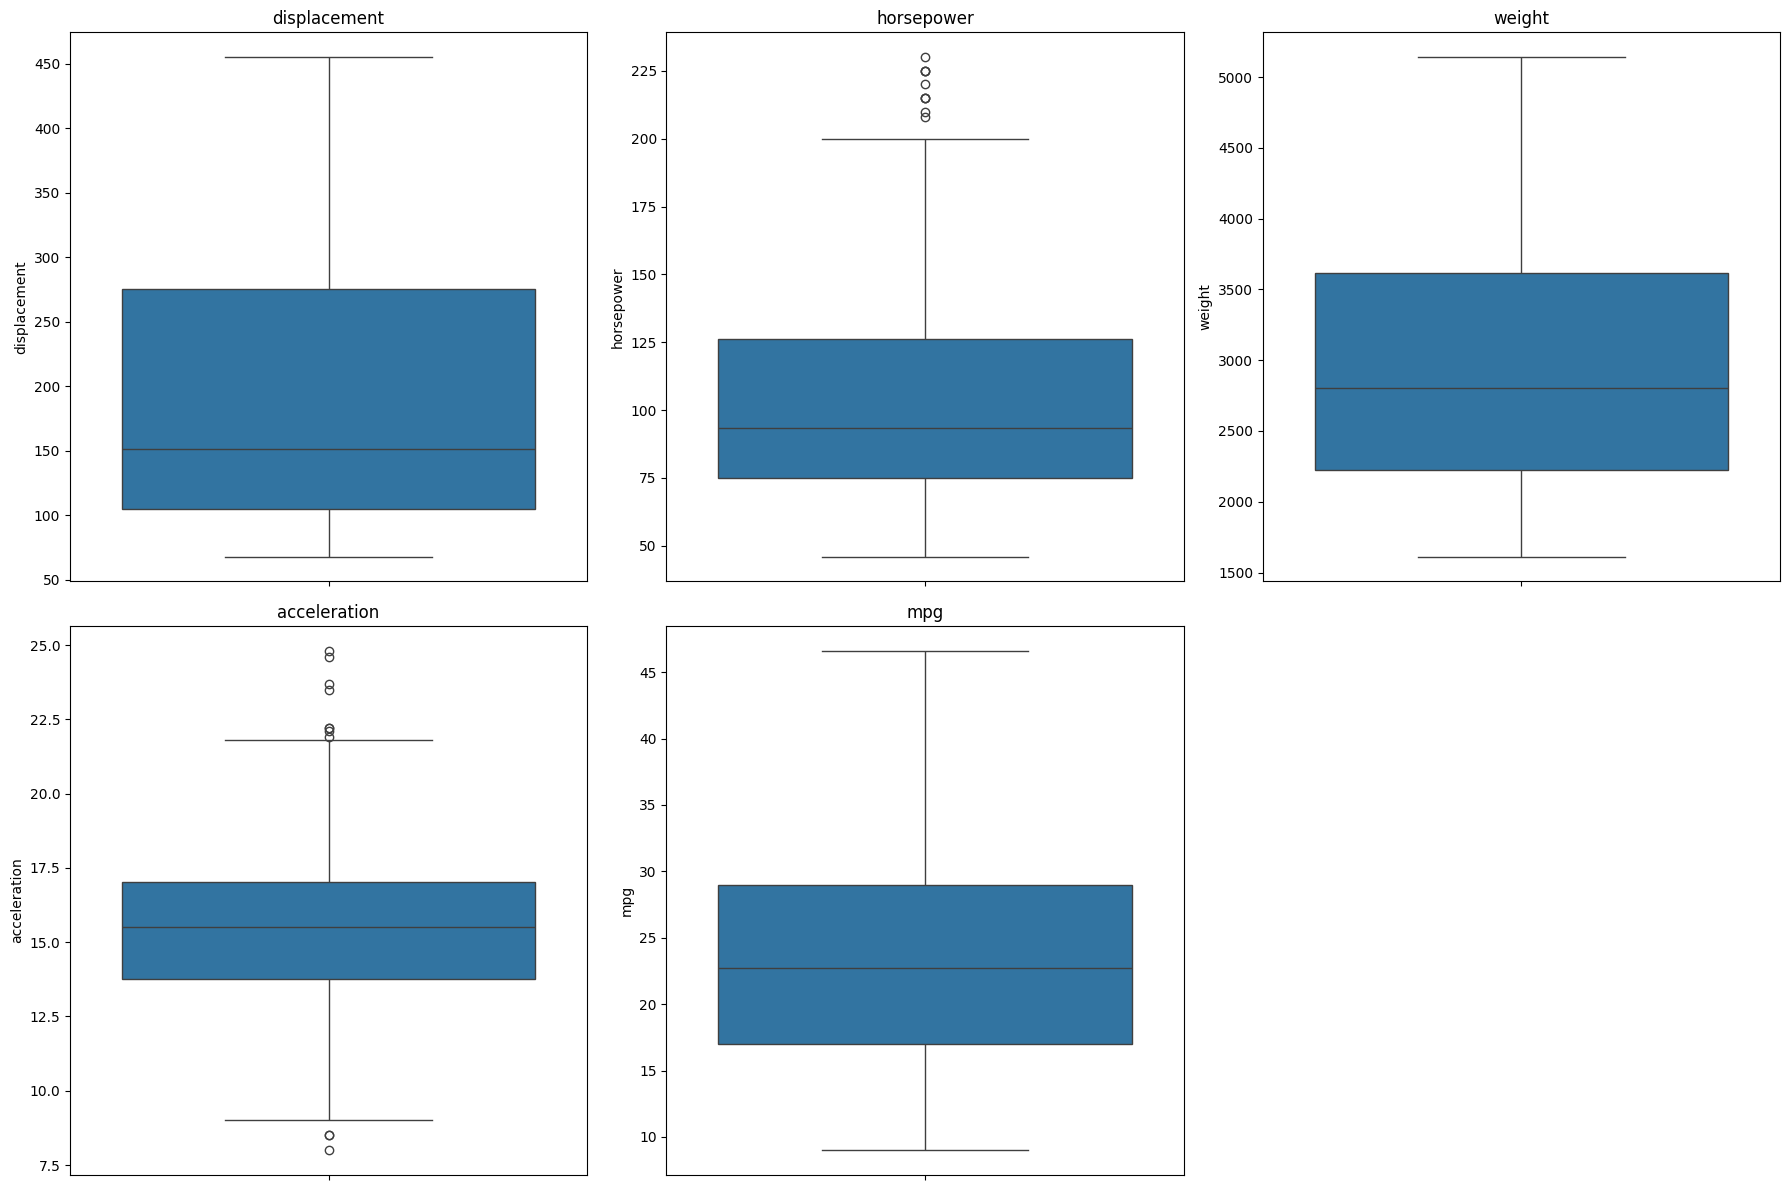

In [61]:
plt.figure(figsize=(18,12))
for i, col in enumerate(['displacement','horsepower','weight','acceleration', 'mpg']):
    plt.subplot(2,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
    plt.ylabel(col)

plt.tight_layout()
plt.savefig('Auto_MPG/boxplots.png',dpi=400,bbox_inches='tight')
plt.show()

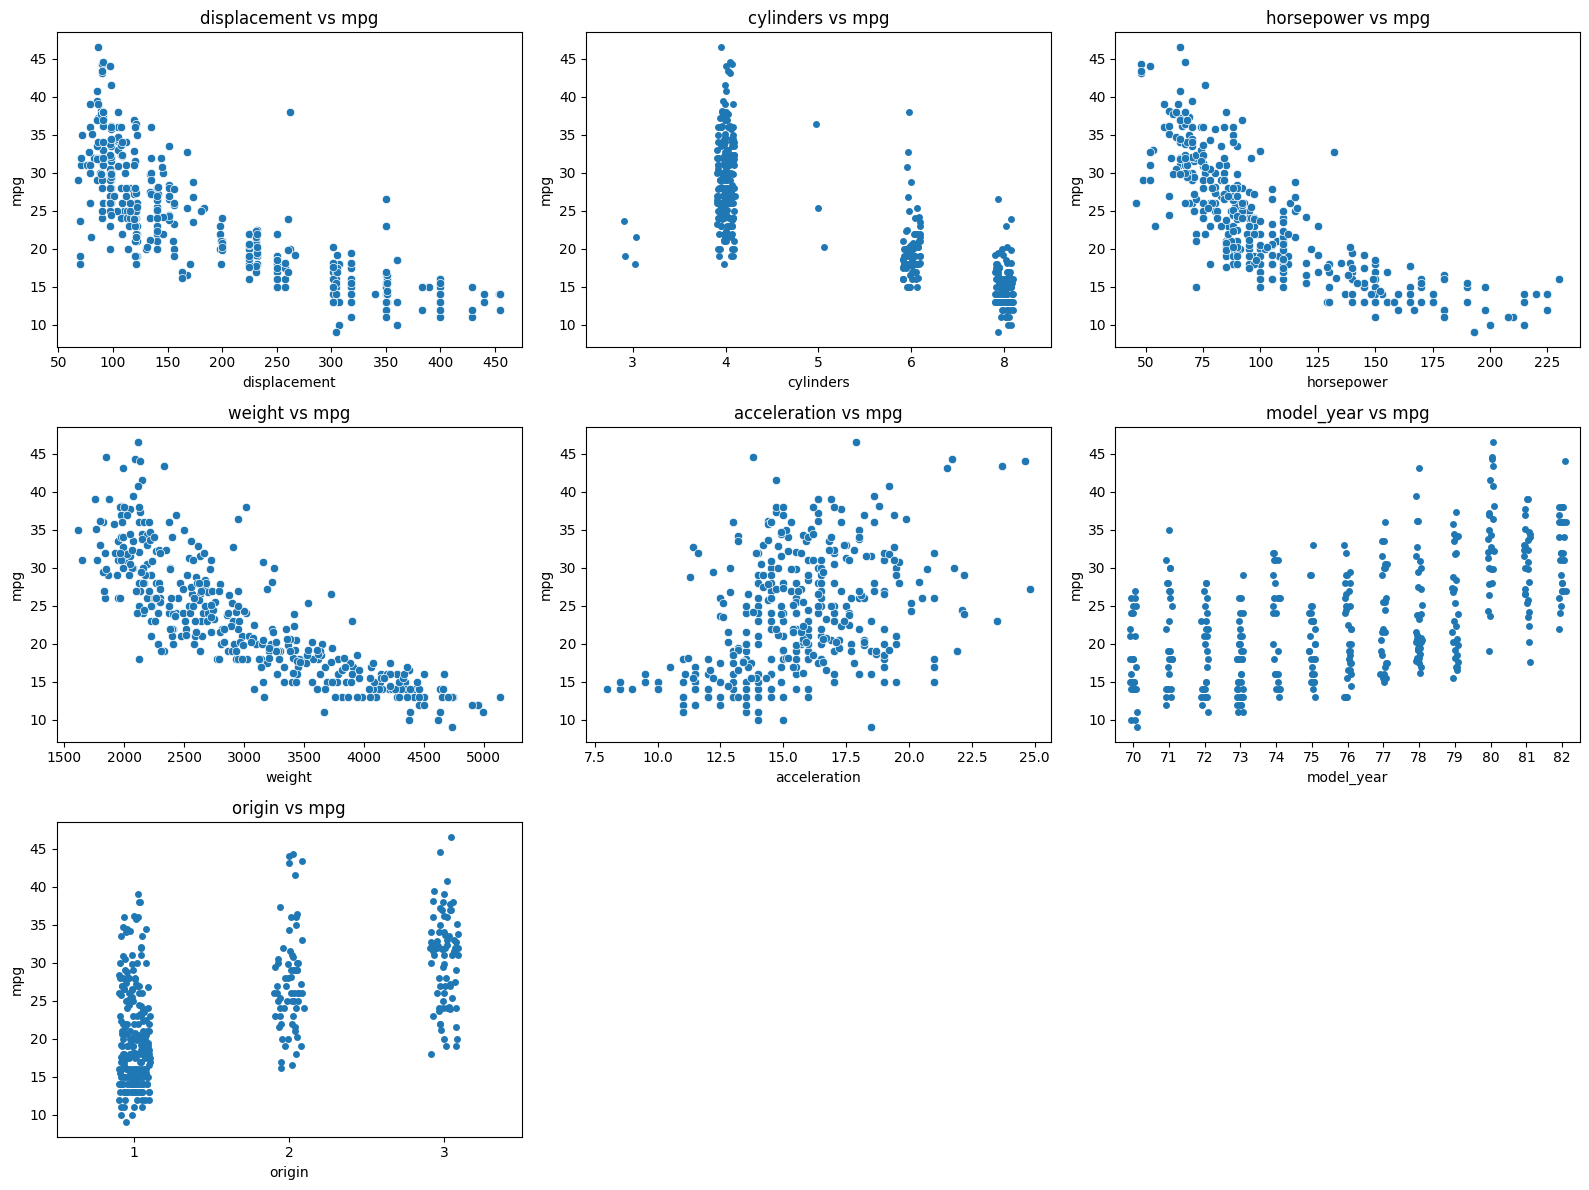

In [62]:
features = ['displacement','cylinders','horsepower','weight','acceleration','model_year','origin']
df['cylinders'] = df['cylinders'].astype('category')
df['origin'] = df['origin'].astype('category')
df['model_year'] = df['model_year'].astype('category')
cats = ['origin', 'cylinders', 'model_year']

plt.figure(figsize=(16,12))
# plt.figure(figsize=(12,8))

for i, col in enumerate(features):
    plt.subplot(3,3,i+1)
    if col not in cats:
        sns.scatterplot(x=df[col], y=df['mpg'])
    else:
        sns.stripplot(x=df[col], y=df['mpg'])
    plt.title(f"{col} vs mpg")

plt.tight_layout()
plt.savefig('Auto_MPG/scatterplots.png',dpi=400,bbox_inches='tight')
plt.show()

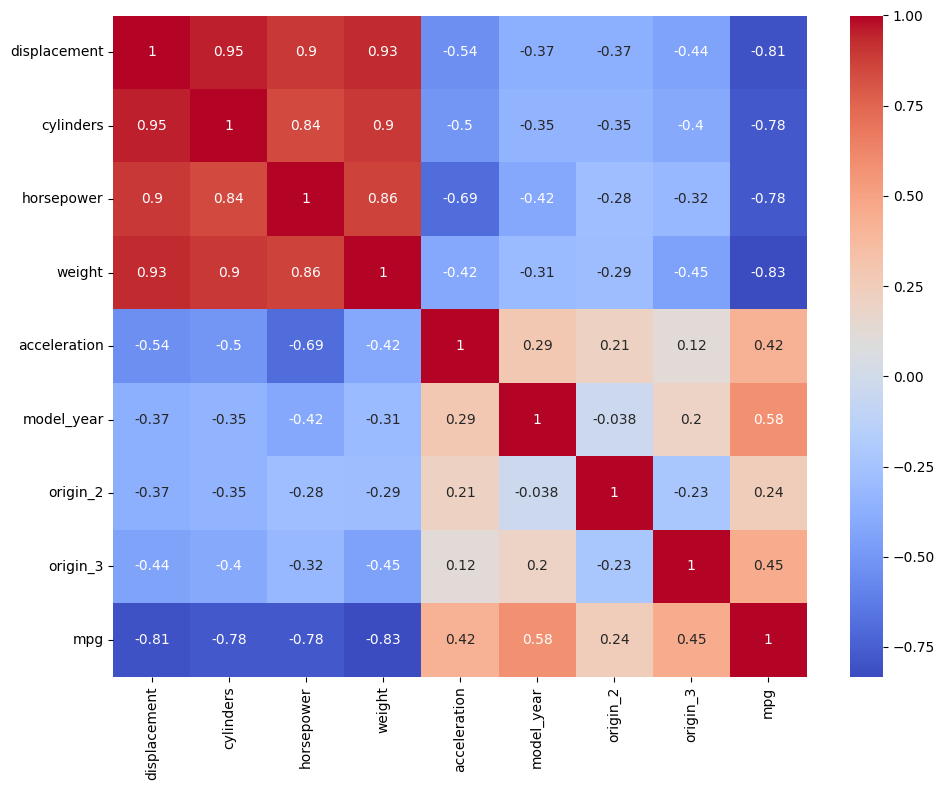

In [63]:
corr = df_encoded.drop('intercept', axis=1).corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr , annot = True , cmap = 'coolwarm')

plt.tight_layout()
plt.savefig('Auto_MPG/correlation_heatmap.png',dpi = 300,bbox_inches='tight')
plt.show()

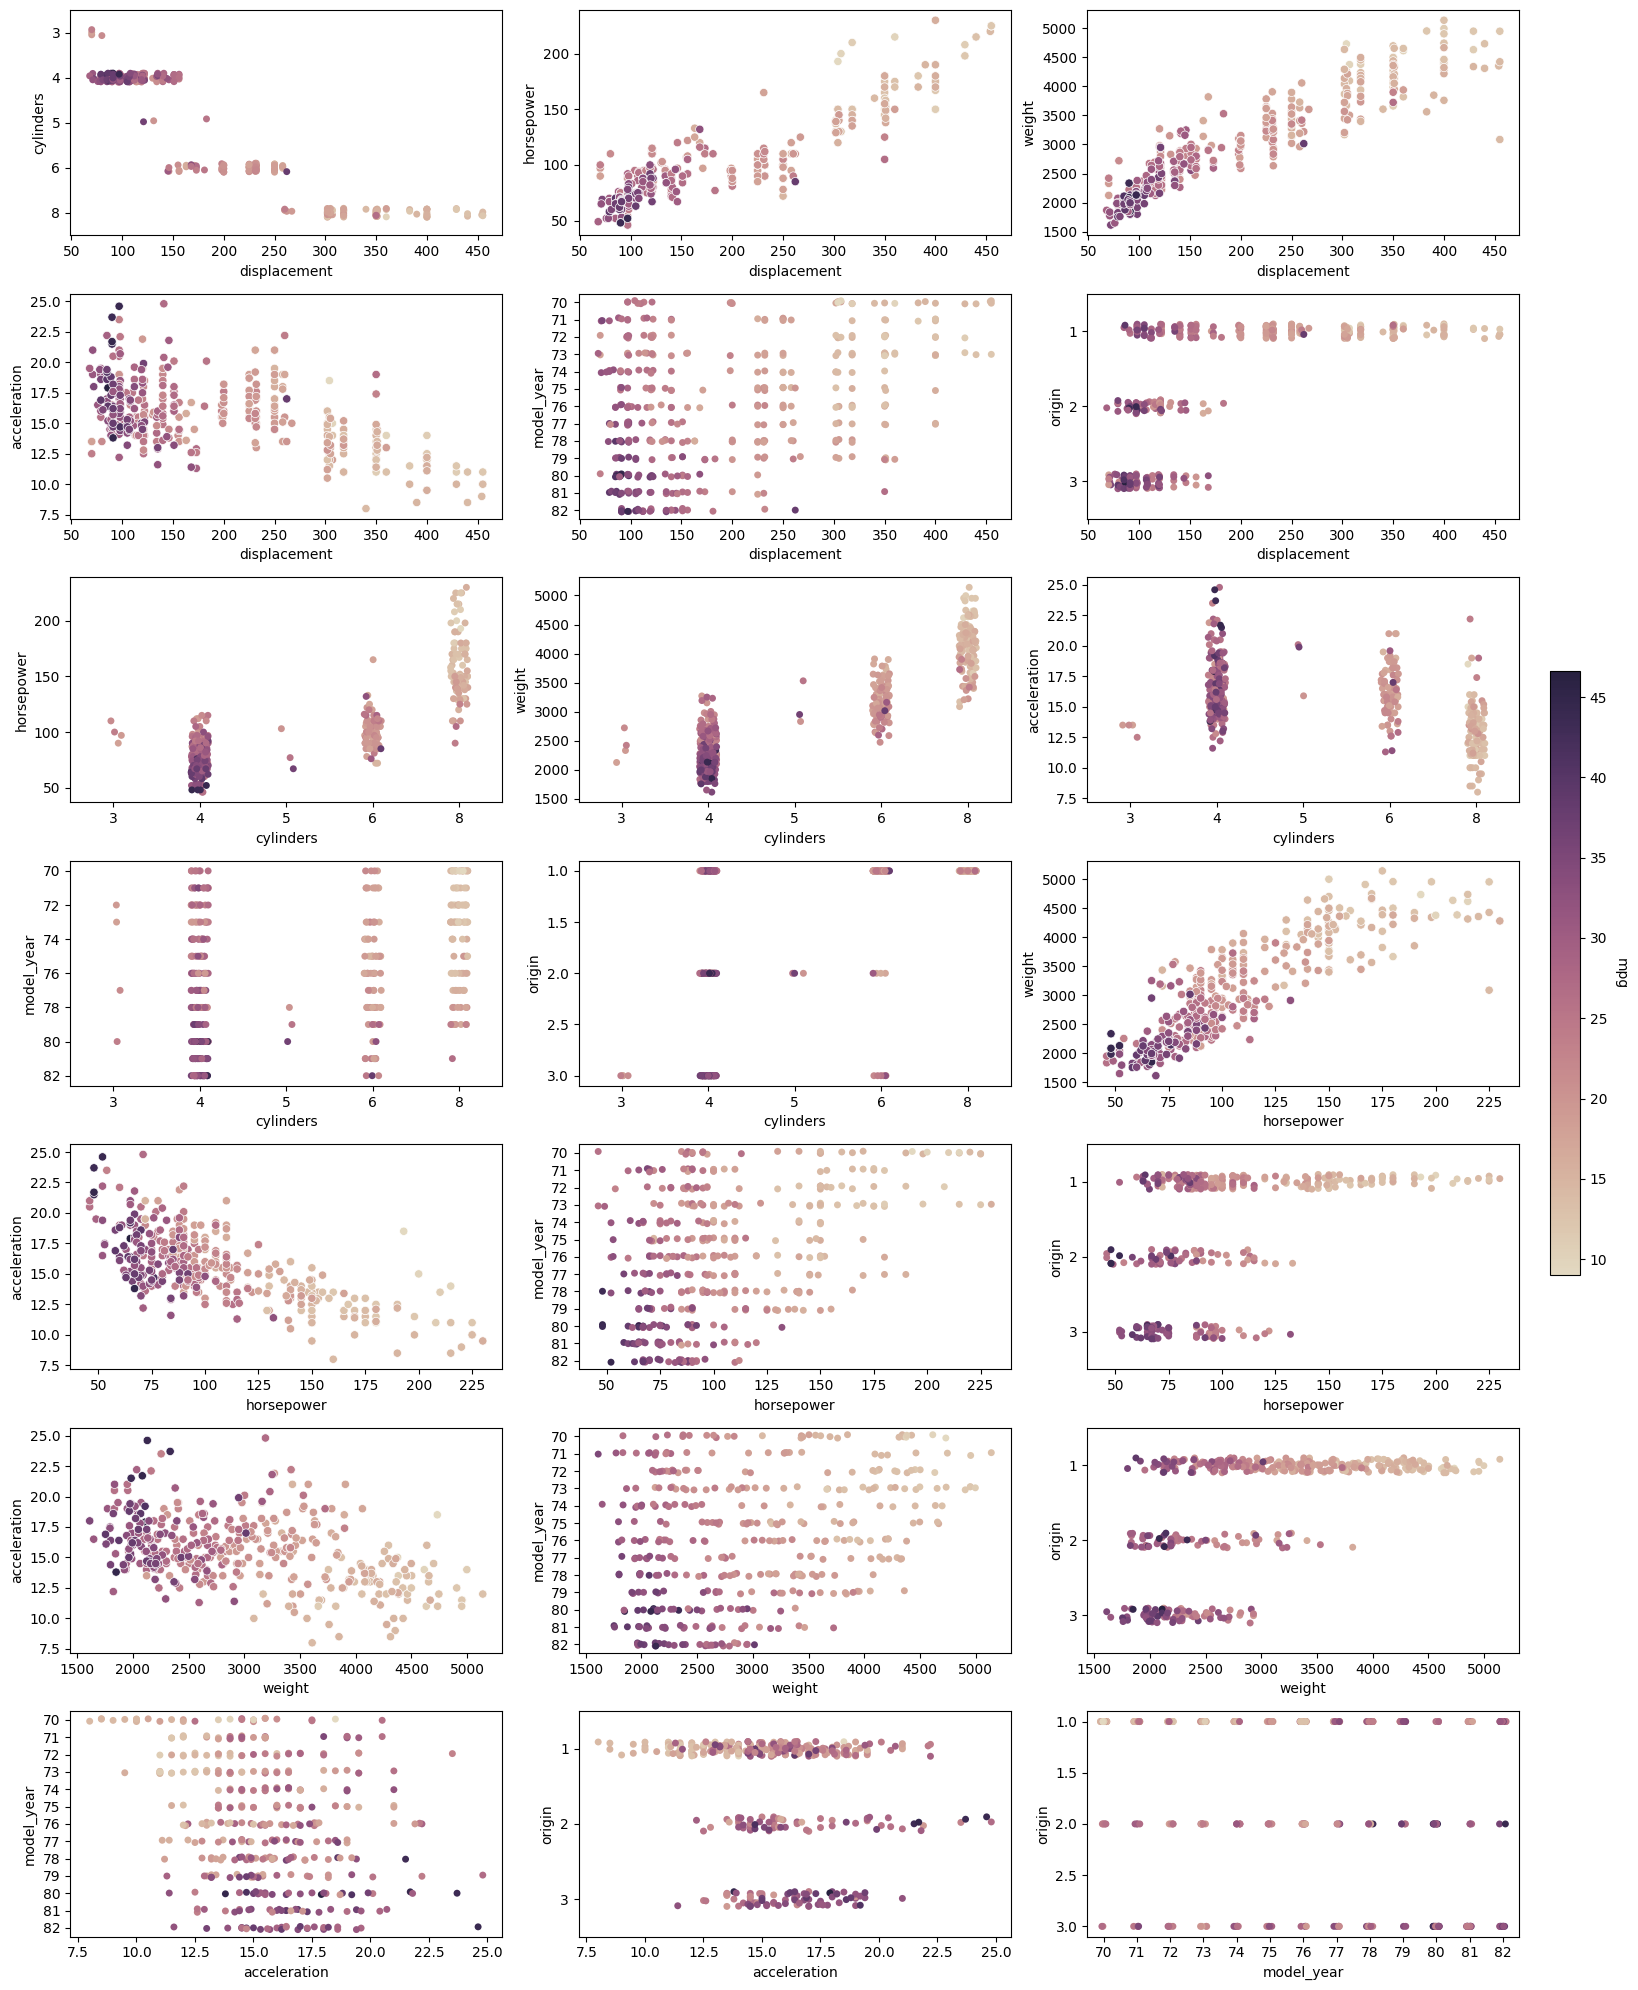

In [64]:
my_norm = colors.Normalize(vmin=df['mpg'].min(), vmax=df['mpg'].max())
# sns.cubehelix_palette(as_cmap=True)
my_cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)

n = 1
fig = plt.figure(figsize=(16, 20))

for i in range(len(features)-1):
    for j in range(i+1, len(features)):
        plt.subplot(7, 3, n)
        
        if (features[i] not in cats) and (features[j] not in cats):
            sns.scatterplot(x=features[i], y=features[j], hue='mpg', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        else:
            sns.stripplot(x=features[i], y=features[j], hue='mpg', data=df, palette=my_cmap, hue_norm=my_norm, legend=False)
        
        plt.xlabel(features[i])
        plt.ylabel(features[j])
        n = n + 1

plt.tight_layout()

sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=my_norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=fig.axes, fraction=0.02, pad=0.02)
cbar.set_label('mpg', rotation=270, labelpad=15)

plt.savefig('Auto_MPG/Hue_Plots.png',dpi=400,bbox_inches='tight')
plt.show()